In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')


import warnings
warnings.filterwarnings('ignore')

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten,GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
test_data = '/kaggle/input/brain-tumor-mri-dataset/Testing'
train_data = '/kaggle/input/brain-tumor-mri-dataset/Training'

In [4]:
image_size = (256, 256)
batch_size=32

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    horizontal_flip=True,
    channel_shift_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
train_gen = train_datagen.flow_from_directory(
    train_data,
    target_size=image_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_data,
    target_size=image_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [7]:
class_names= os.listdir('/kaggle/input/brain-tumor-mri-dataset/Training')
n_classes = len(class_names)
print(f"Total Number of Classes : {n_classes} \nClass Names : {class_names}")

Total Number of Classes : 4 
Class Names : ['pituitary', 'notumor', 'meningioma', 'glioma']


In [8]:
print(f"Training samples: {len(train_gen)}")
print(f"Testing samples: {len(test_gen)}")

Training samples: 179
Testing samples: 41


Training Images:


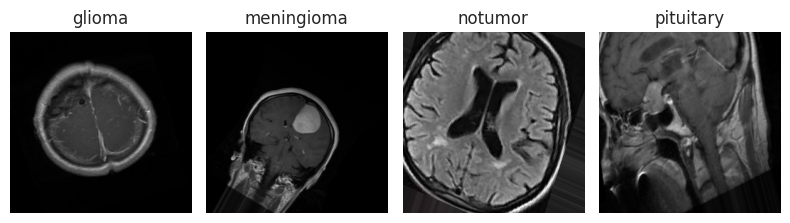

Testing Images:


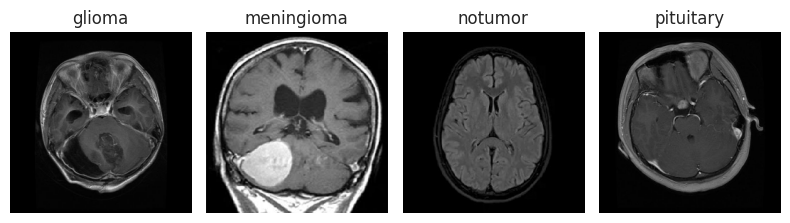

In [9]:
def display_one_image_per_class(generator, num_classes=4):
    plt.figure(figsize=(8, 5))
    class_labels = list(generator.class_indices.keys())
    
    for class_index in range(num_classes):
        while True:
            images, labels = next(generator)
            if np.argmax(labels[0]) == class_index:
                plt.subplot(1, num_classes, class_index + 1)
                plt.imshow(images[0])
                plt.axis('off')
                plt.title(f"{class_labels[class_index]}")
                break

    plt.tight_layout()
    plt.show()

print("Training Images:")
display_one_image_per_class(train_gen, num_classes=4)

print("Testing Images:")
display_one_image_per_class(test_gen, num_classes=4)

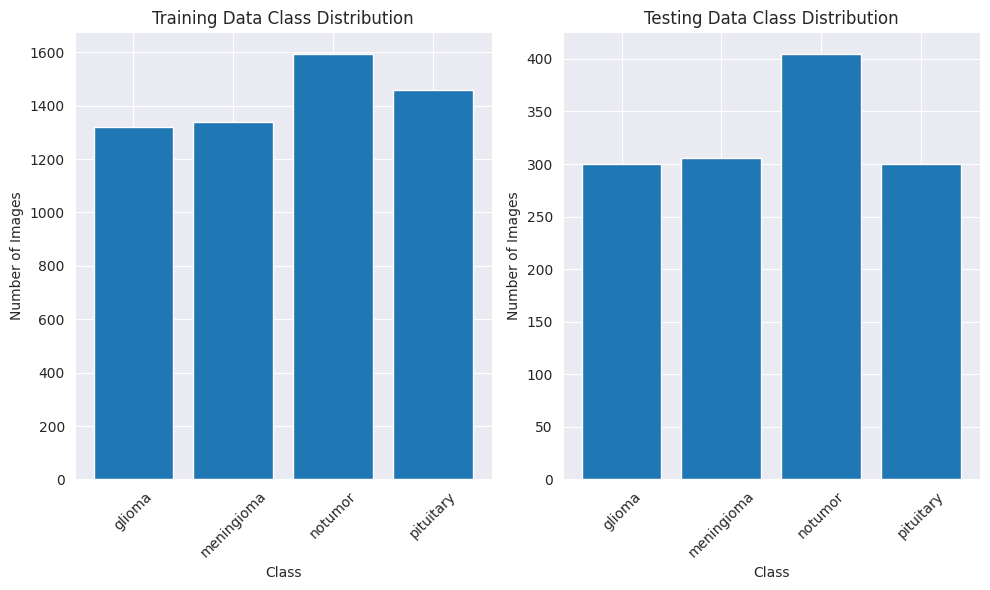

In [10]:
def plot_class_distribution(train_gen, test_gen):
    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    class_counts_train = train_gen.classes
    unique_train, counts_train = np.unique(class_counts_train, return_counts=True)
    plt.bar(unique_train, counts_train, tick_label=list(train_gen.class_indices.keys()))
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.title('Training Data Class Distribution')
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    class_counts_test = test_gen.classes
    unique_test, counts_test = np.unique(class_counts_test, return_counts=True)
    plt.bar(unique_test, counts_test, tick_label=list(test_gen.class_indices.keys()))
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.title('Testing Data Class Distribution')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


plot_class_distribution(train_gen, test_gen)

In [11]:
input_shape = [256, 256, 3]
l2_lambda = 0.002

# Learning Rate Scheduler
adam = Adam(
    learning_rate=0.001
)

model = Sequential()


# Convolutional Layers
model.add(Conv2D(64, (3, 3), padding="same", activation="relu", input_shape=input_shape, kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))  

model.add(Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))  

model.add(Conv2D(256, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.5)) 

model.add(Conv2D(512, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.5))  


model.add(Flatten())

# Dense Layers
model.add(Dense(512, activation='relu', kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(Dropout(0.5)) 

model.add(Dense(256, activation='relu', kernel_regularizer=l2(l2_lambda)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(n_classes, activation='softmax'))

# Compile the model
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 71,937,860 (274.42 MB)

 Trainable params: 71,932,484 (274.40 MB)

 Non-trainable params: 5,376 (21.00 KB)

In [13]:
# Train the model
epochs =30
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    train_gen, 
    epochs= epochs, 
    verbose= 1, 
    validation_data=test_gen,
    callbacks=[early_stopping,reduce_lr],
    shuffle= False
)

Epoch 1/30


I0000 00:00:1727857025.369947     124 service.cc:145] XLA service 0x7e806800ab30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1727857025.370009     124 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1727857025.370015     124 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1727857090.479124     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.4449 - loss: 10.7757 - val_accuracy: 0.2288 - val_loss: 13.4746 - learning_rate: 0.0010
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 110s 611ms/step - accuracy: 0.5324 - loss: 8.3500 - val_accuracy: 0.2510 - val_loss: 6.5652 - learning_rate: 0.0010
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 110s 614ms/step - accuracy: 0.6231 - loss: 5.4816 - val_accuracy: 0.4081 - val_loss: 4.7075 - learning_rate: 0.0010
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 110s 614ms/step - accuracy: 0.6789 - loss: 4.1762 - val_accuracy: 0.3440 - val_loss: 5.5549 - learning_rate: 0.0010
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 111s 617ms/step - accuracy: 0.6533 - loss: 3.5377 - val_accuracy: 0.4249 - val_loss: 4.4195 - learning_rate: 0.0010
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 109s 604ms/step - accuracy: 0.6906 - loss: 2.9621 - val_accuracy: 0.6834 - val_loss: 2.7447 - learning_rate: 0.0010
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 109s 609ms/step - accuracy: 0.6937 -

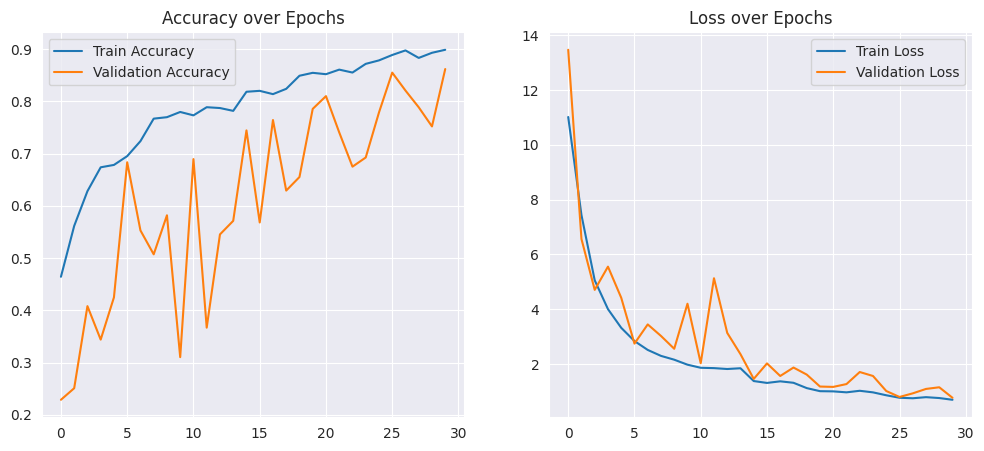

In [14]:
# Plot accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [15]:
# Evaluate the model on the training data
train_loss, train_accuracy = model.evaluate(train_gen)
print(f'Training Accuracy: {train_accuracy:.2f}')

179/179 ━━━━━━━━━━━━━━━━━━━━ 102s 569ms/step - accuracy: 0.8871 - loss: 0.6737
Training Accuracy: 0.89


In [16]:
test_loss, test_accuracy = model.evaluate(test_gen)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.8334 - loss: 0.8386
Test accuracy: 86.19%


41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step


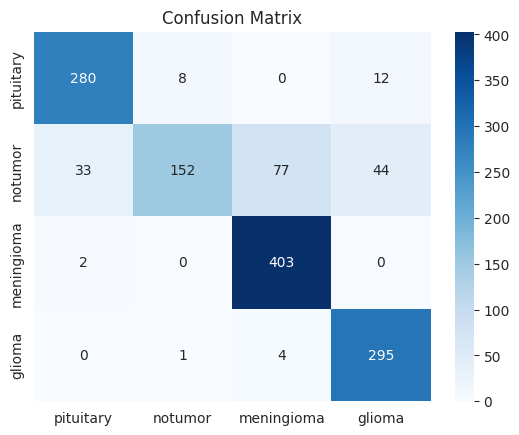

In [17]:
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()

In [18]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   pituitary       0.89      0.93      0.91       300
     notumor       0.94      0.50      0.65       306
  meningioma       0.83      1.00      0.91       405
      glioma       0.84      0.98      0.91       300

    accuracy                           0.86      1311
   macro avg       0.88      0.85      0.84      1311
weighted avg       0.87      0.86      0.85      1311



In [19]:
model.save('brain_tumor_classifier.h5')

In [20]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

vgg = VGG16(input_shape=(256, 256, 3), include_top=False, weights='imagenet')


for layer in vgg.layers[-4:]:  # Unfreeze the last 4 layers
    layer.trainable = True
    
x = Flatten()(vgg.output)
x = Dense(1024, activation='relu')(x)  
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(n_classes, activation='softmax')(x)  

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
vgg_model = Model(vgg.input, x)


vgg_model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history_vgg = vgg_model.fit(
    train_gen,
    epochs=30,
    validation_data=test_gen,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 140s 678ms/step - accuracy: 0.2417 - loss: 2.2293 - val_accuracy: 0.4386 - val_loss: 1.2367 - learning_rate: 1.0000e-05
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 114s 614ms/step - accuracy: 0.3129 - loss: 1.8669 - val_accuracy: 0.6438 - val_loss: 0.8992 - learning_rate: 1.0000e-05
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 114s 614ms/step - accuracy: 0.4432 - loss: 1.3487 - val_accuracy: 0.7048 - val_loss: 0.7395 - learning_rate: 1.0000e-05
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 115s 616ms/step - accuracy: 0.5909 - loss: 1.0258 - val_accuracy: 0.7285 - val_loss: 0.7354 - learning_rate: 1.0000e-05
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 114s 615ms/step - accuracy: 0.6708 - loss: 0.8337 - val_accuracy: 0.7864 - val_loss: 0.6280 - learning_rate: 1.0000e-05
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 114s 611ms/step - accuracy: 0.7339 - loss: 0.7008 - val_accuracy: 0.8017 - val_loss: 0.6377 - learning_rate: 1.0000e-05
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 

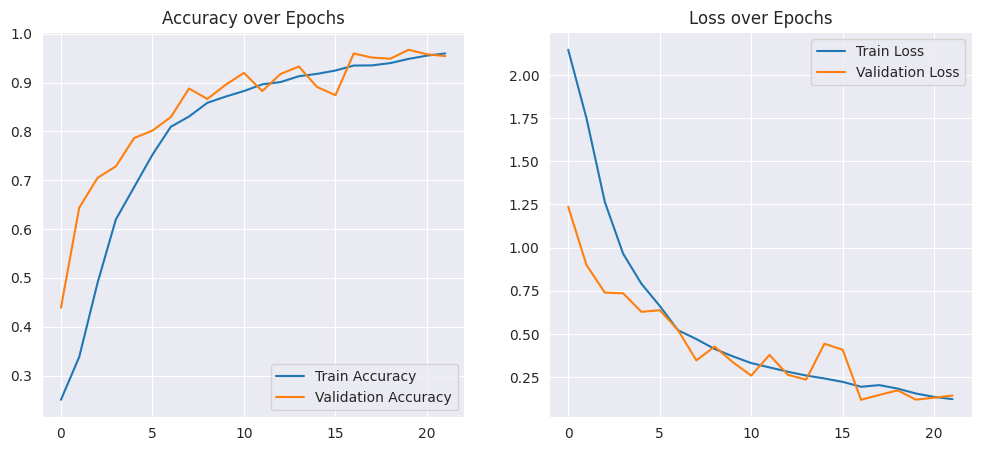

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [23]:
test_loss_vgg, test_accuracy_vgg = vgg_model.evaluate(test_gen)
print(f'VGG16 Test accuracy: {test_accuracy_vgg *100 :.2f}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.9515 - loss: 0.1368
VGG16 Test accuracy: 95.96


41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step


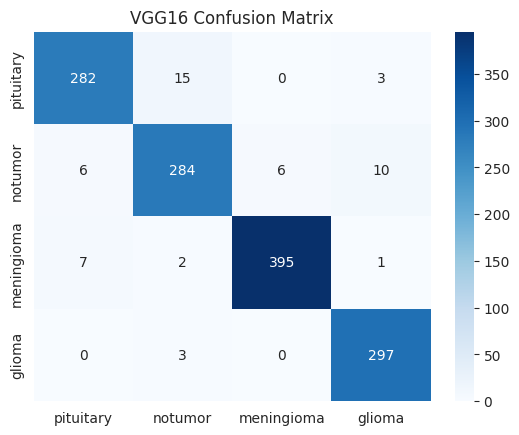

              precision    recall  f1-score   support

   pituitary       0.96      0.94      0.95       300
     notumor       0.93      0.93      0.93       306
  meningioma       0.99      0.98      0.98       405
      glioma       0.95      0.99      0.97       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



In [24]:
y_pred_vgg = np.argmax(vgg_model.predict(test_gen), axis=1)
y_true_vgg = test_gen.classes

cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

sns.heatmap(cm_vgg, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title('VGG16 Confusion Matrix')
plt.show()

print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))

In [25]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(input_shape=(256, 256, 3), include_top=False, weights='imagenet')

for layer in base_model.layers[-4:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(n_classes, activation='softmax')(x)  
resnet_model = Model(inputs=base_model.input, outputs=x)

resnet_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history_resnet = resnet_model.fit(
    train_gen,
    epochs=8,
    validation_data=test_gen,
    callbacks=[early_stopping, reduce_lr]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8


I0000 00:00:1727863201.673393     126 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_30', 20 bytes spill stores, 20 bytes spill loads



179/179 ━━━━━━━━━━━━━━━━━━━━ 211s 792ms/step - accuracy: 0.6319 - loss: 0.9500 - val_accuracy: 0.3089 - val_loss: 1.8091 - learning_rate: 1.0000e-04
Epoch 2/8
179/179 ━━━━━━━━━━━━━━━━━━━━ 110s 588ms/step - accuracy: 0.8979 - loss: 0.3068 - val_accuracy: 0.3097 - val_loss: 2.1452 - learning_rate: 1.0000e-04
Epoch 3/8
179/179 ━━━━━━━━━━━━━━━━━━━━ 110s 590ms/step - accuracy: 0.9397 - loss: 0.1807 - val_accuracy: 0.3646 - val_loss: 2.1159 - learning_rate: 1.0000e-04
Epoch 4/8
179/179 ━━━━━━━━━━━━━━━━━━━━ 110s 589ms/step - accuracy: 0.9513 - loss: 0.1452 - val_accuracy: 0.6079 - val_loss: 1.1672 - learning_rate: 1.0000e-04
Epoch 5/8
179/179 ━━━━━━━━━━━━━━━━━━━━ 143s 595ms/step - accuracy: 0.9565 - loss: 0.1312 - val_accuracy: 0.7895 - val_loss: 0.5210 - learning_rate: 1.0000e-04
Epoch 6/8
179/179 ━━━━━━━━━━━━━━━━━━━━ 110s 590ms/step - accuracy: 0.9644 - loss: 0.1101 - val_accuracy: 0.9314 - val_loss: 0.2542 - learning_rate: 1.0000e-04
Epoch 7/8
179/179 ━━━━━━━━━━━━━━━━━━━━ 109s 587ms/step -

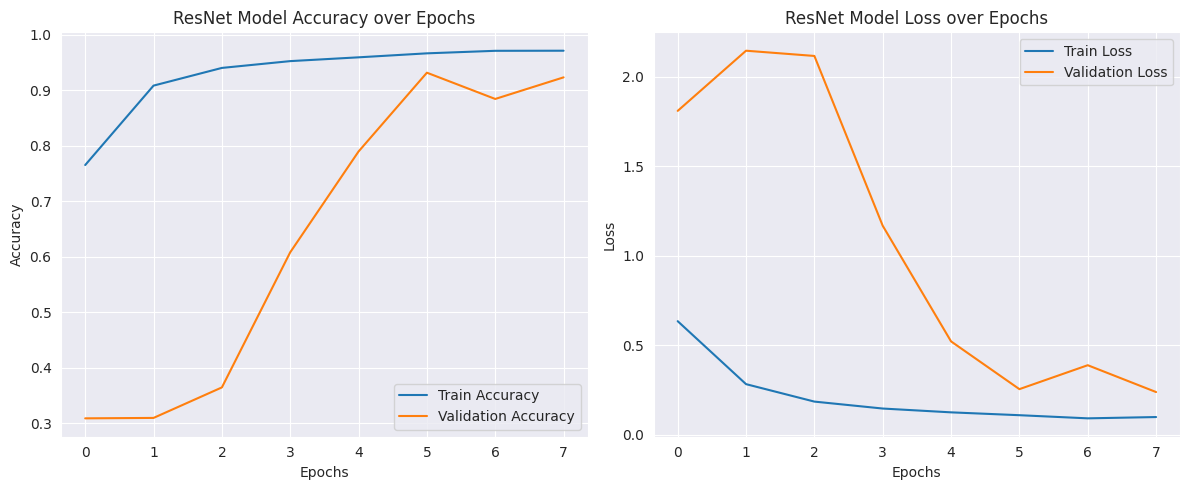

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('ResNet Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
test_loss, test_accuracy = resnet_model.evaluate(test_gen)
print(f'ResNet Test Accuracy: {test_accuracy * 100:.2f}%')

41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9244 - loss: 0.2299
ResNet Test Accuracy: 92.30%


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step


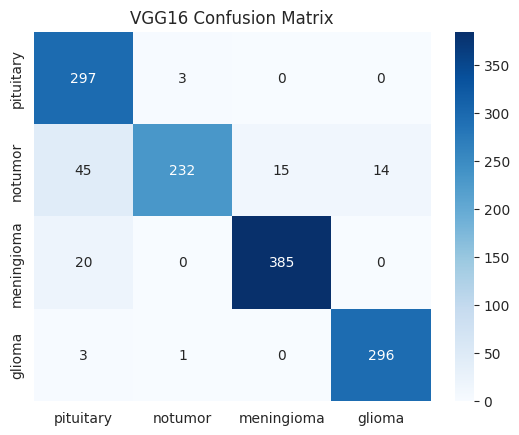

              precision    recall  f1-score   support

   pituitary       0.81      0.99      0.89       300
     notumor       0.98      0.76      0.86       306
  meningioma       0.96      0.95      0.96       405
      glioma       0.95      0.99      0.97       300

    accuracy                           0.92      1311
   macro avg       0.93      0.92      0.92      1311
weighted avg       0.93      0.92      0.92      1311



In [29]:
y_pred_resnet = np.argmax(resnet_model.predict(test_gen), axis=1)
y_true_resnet = test_gen.classes

cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)

sns.heatmap(cm_resnet, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title('VGG16 Confusion Matrix')
plt.show()

print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))

In [30]:
vgg_model.save('vgg_model.h5')
print("VGG model saved as 'vgg_model.h5'.")

# Save ResNet model
resnet_model.save('resnet_model.h5')
print("ResNet model saved as 'resnet_model.h5'.")

VGG model saved as 'vgg_model.h5'.
ResNet model saved as 'resnet_model.h5'.
